# 📊 Exploratory Data Analysis (EDA)

## Project Objective

The objective of this notebook is to explore the dataset, identify patterns, detect anomalies, understand feature relationships, and gain insights that will help in feature engineering and model building.

# 1. Import Required Libraries

Import all the libraries required for exploratory data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# 2. Load Dataset

Load the dataset for exploratory data analysis.

In [2]:
df = pd.read_csv("../data/predictive_maintenance.csv")

# 3. Dataset Overview

Display the dataset shape, sample records, and data types.

In [3]:
df.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [4]:
df.shape

(24042, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                24042 non-null  object 
 1   machine_id               24042 non-null  int64  
 2   machine_type             24042 non-null  object 
 3   vibration_rms            23042 non-null  float64
 4   temperature_motor        23208 non-null  float64
 5   current_phase_avg        23311 non-null  float64
 6   pressure_level           23118 non-null  float64
 7   rpm                      23509 non-null  float64
 8   operating_mode           24042 non-null  object 
 9   hours_since_maintenance  24042 non-null  float64
 10  ambient_temp             24042 non-null  float64
 11  rul_hours                24042 non-null  float64
 12  failure_within_24h       24042 non-null  int64  
 13  failure_type             24042 non-null  object 
 14  estimated_repair_cost 

# 4. Feature Categorization

Separate numerical and categorical features for appropriate analysis.

In [6]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("Numerical cols :",num_cols)
print("Categorical cols :",cat_cols)

Numerical cols : ['machine_id', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'estimated_repair_cost']
Categorical cols : ['timestamp', 'machine_type', 'operating_mode', 'failure_type']


# 5. Univariate Analysis

Understand the distribution of individual features.

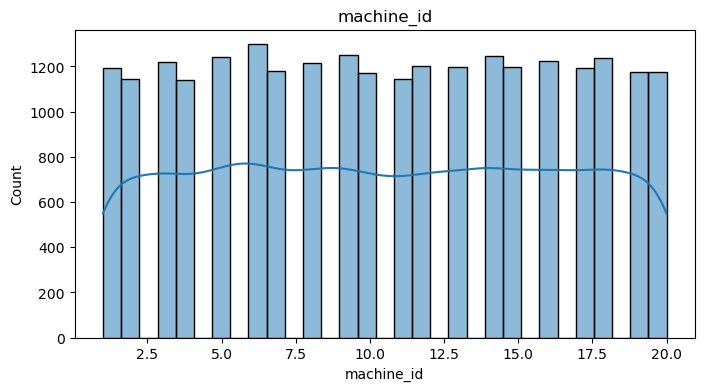

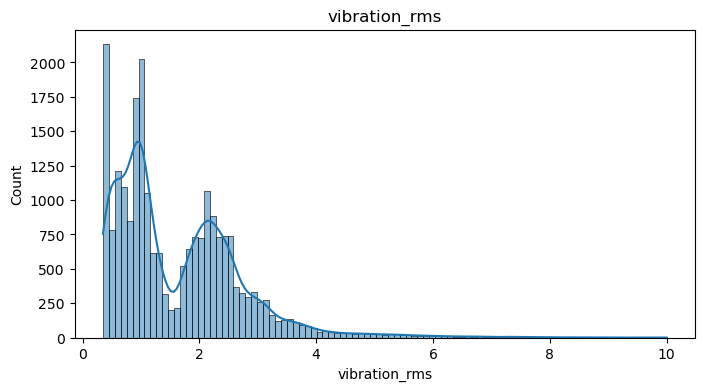

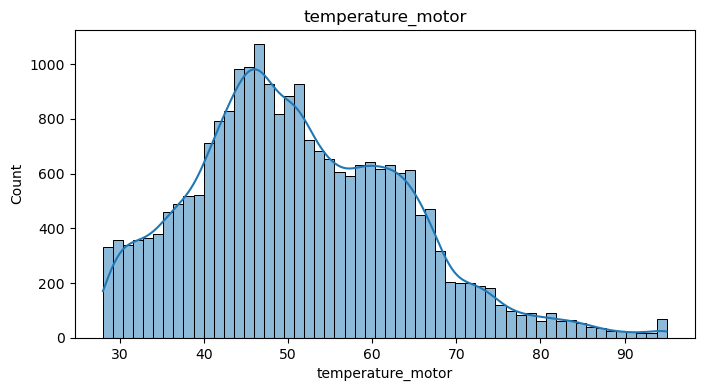

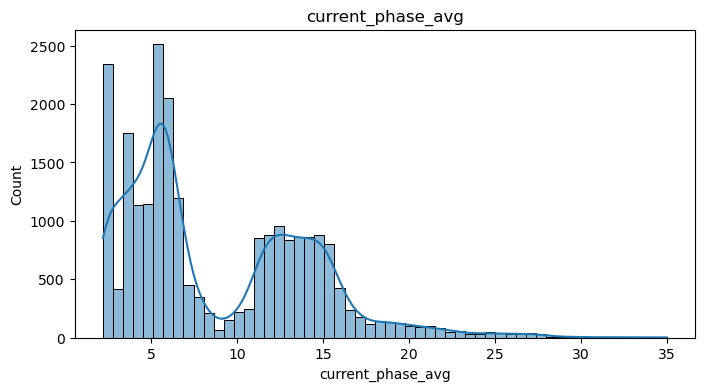

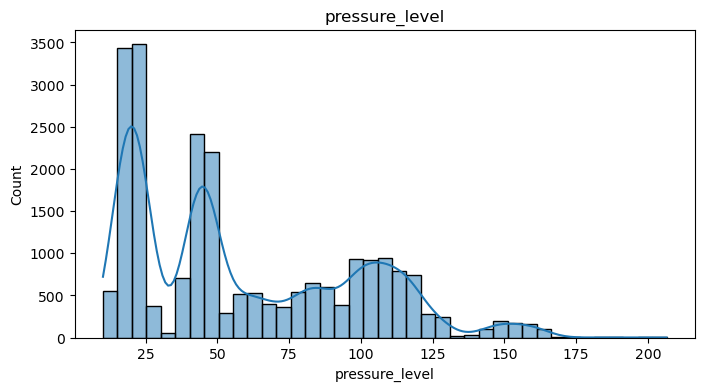

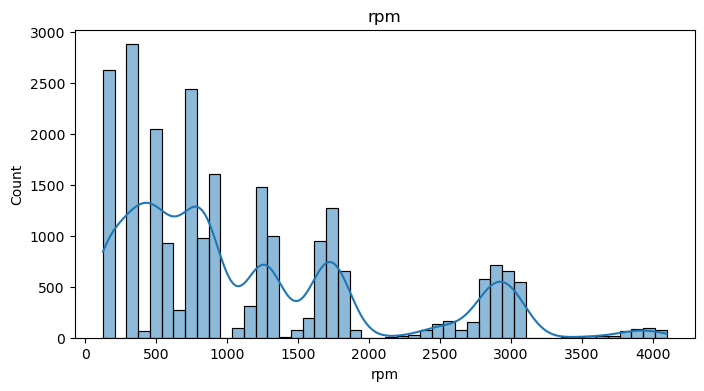

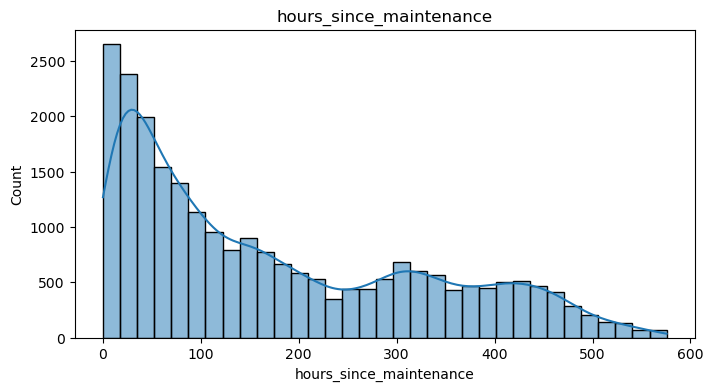

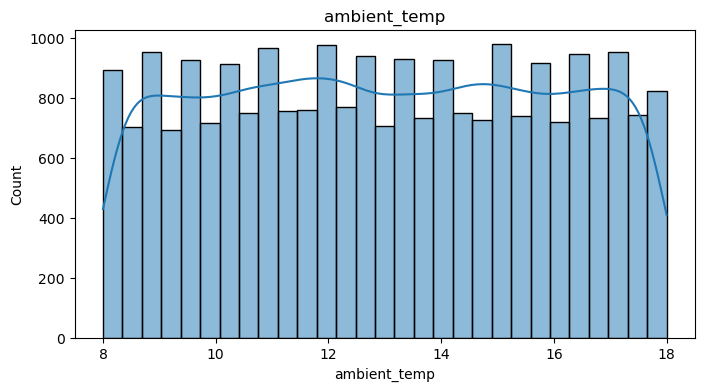

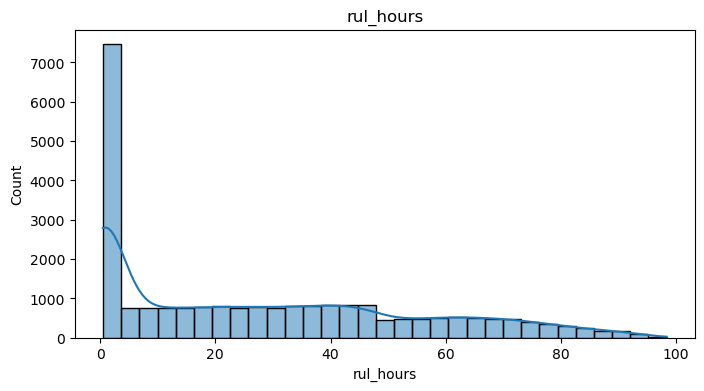

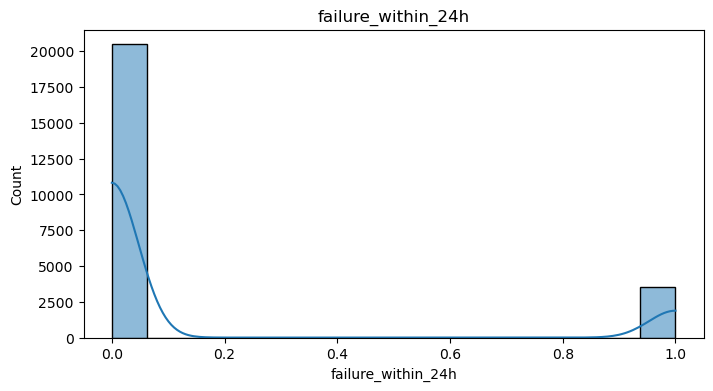

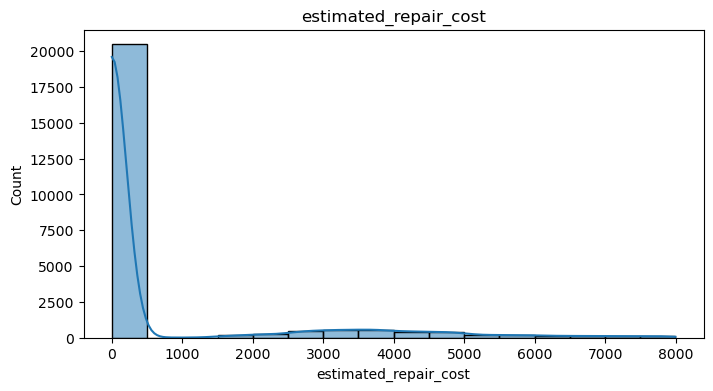

In [7]:

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

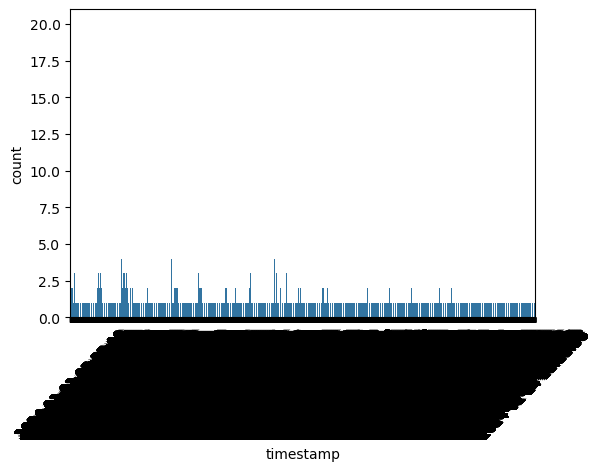

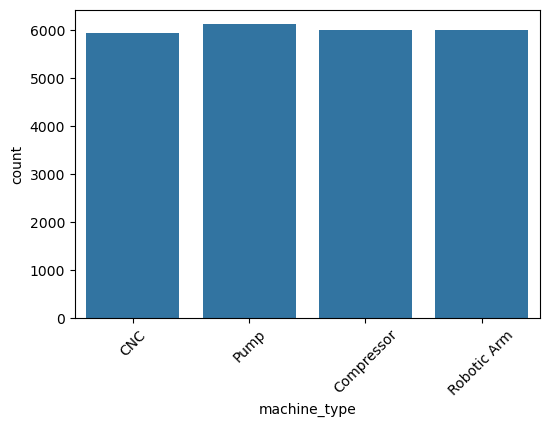

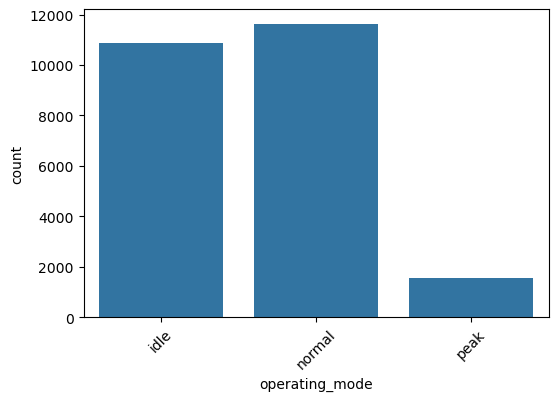

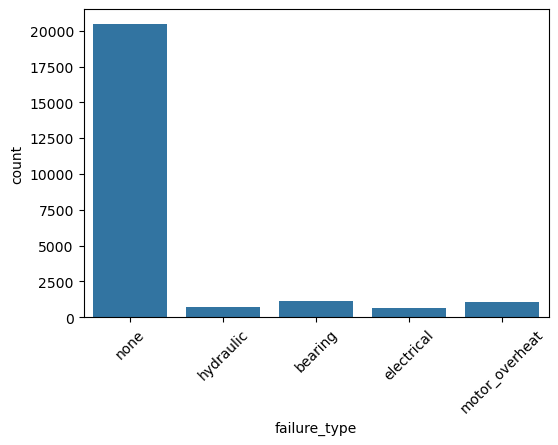

In [8]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.show()

# 6. Target Variable Analysis

Analyze the distribution of the target variable.

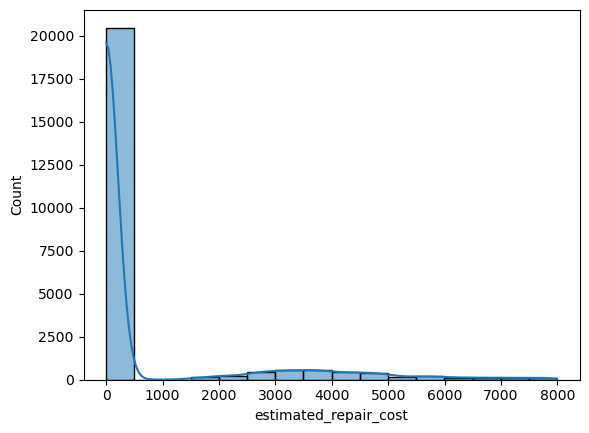

In [9]:
sns.histplot(df["estimated_repair_cost"], kde=True)
plt.show()

# 7. Correlation Analysis

Identify relationships among numerical features.

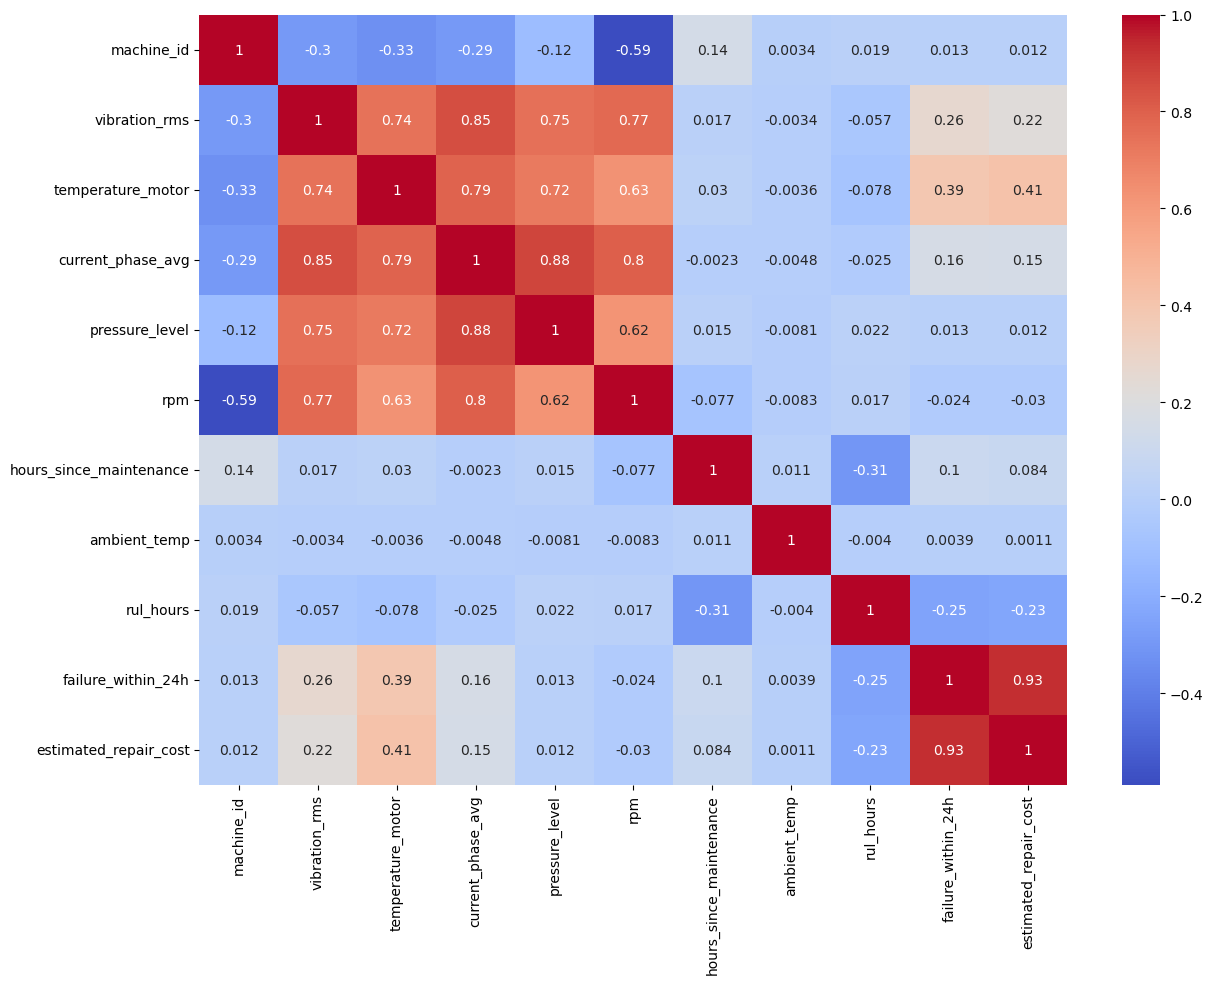

In [10]:
plt.figure(figsize=(14,10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

# 8. Correlation Analysis

Analyze the correlation among numerical features to identify strong linear relationships.

In [ ]:
corr_matrix = df[num_cols].corr()

corr_matrix

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

# 9. Multicollinearity Analysis

Variance Inflation Factor (VIF) is used to identify multicollinearity among numerical features.

A high VIF indicates that a feature is highly correlated with other independent features.


Correlation identifies pairwise linear relationships between features.

VIF identifies multicollinearity among multiple independent variables, which can negatively affect regression models such as Linear Regression.

# 10. Outlier Detection

Detect outliers using boxplots.

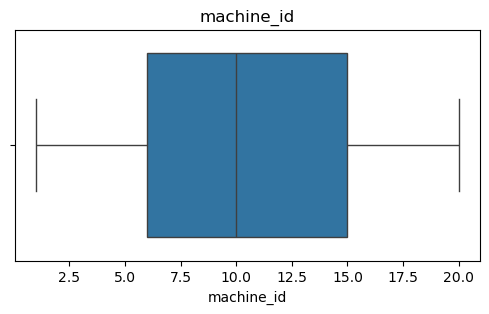

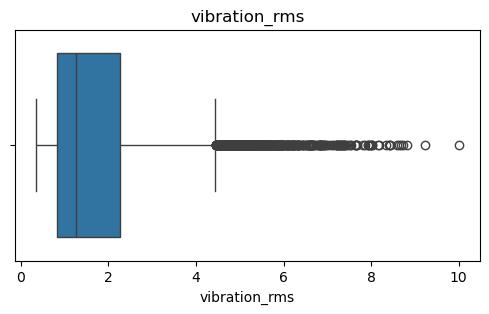

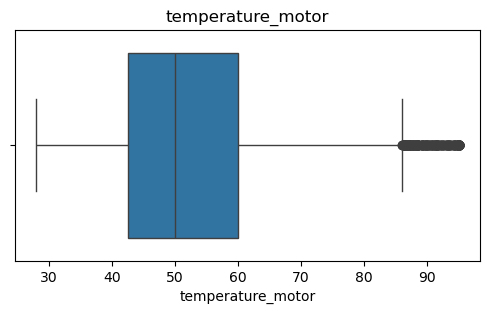

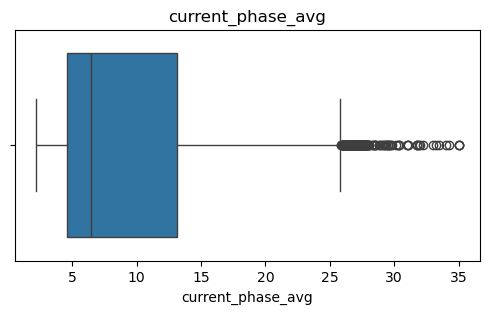

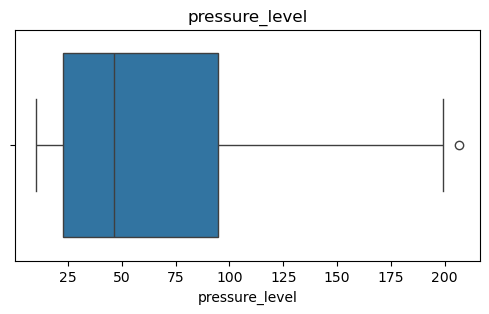

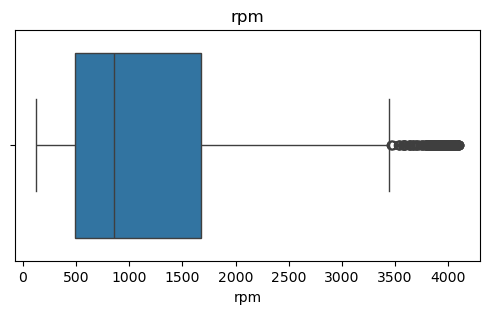

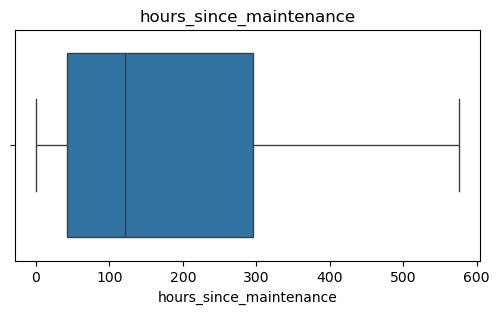

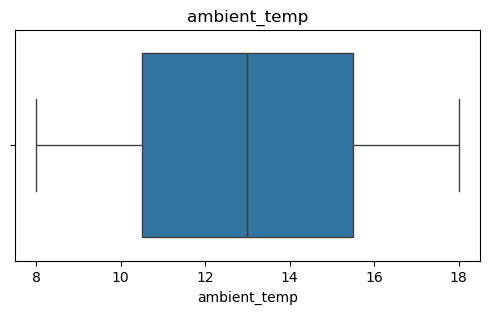

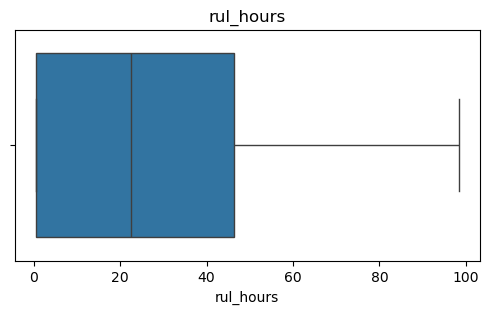

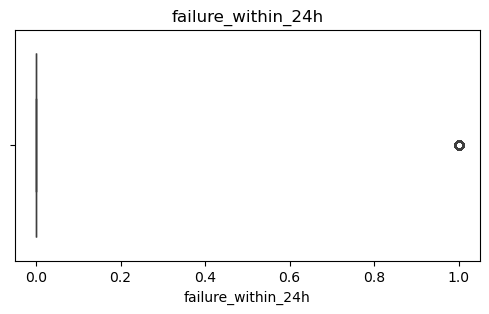

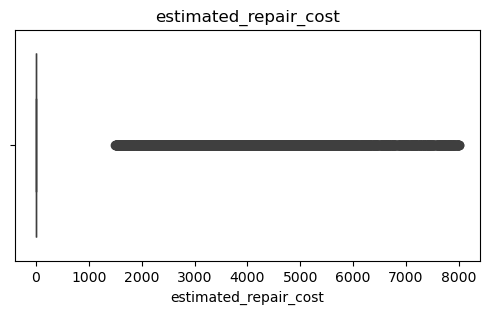

In [16]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# 11. Relationship with Target Variable

Analyze how each feature affects the repair cost.

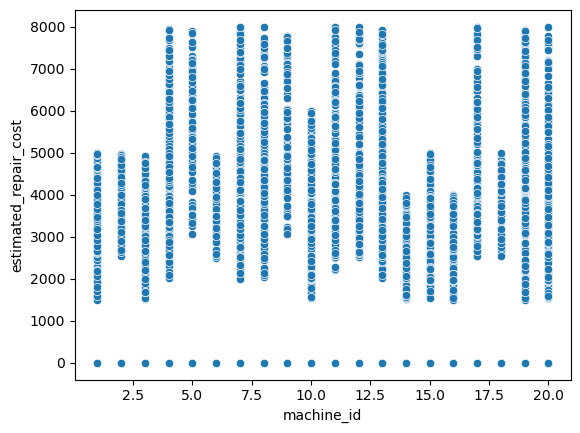

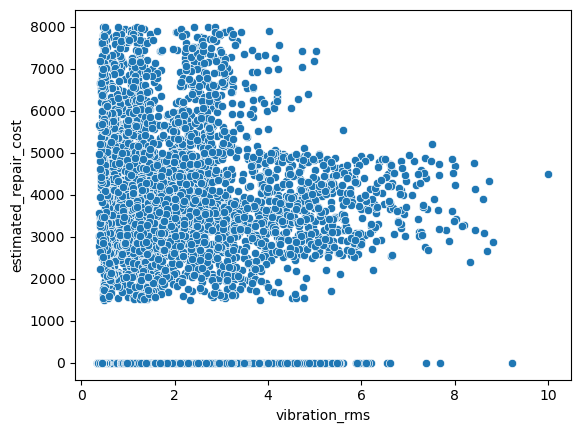

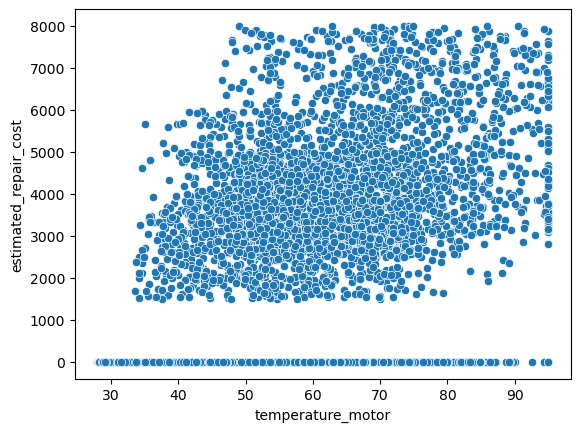

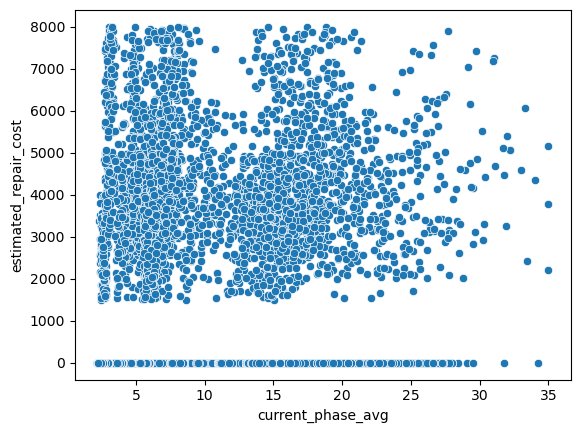

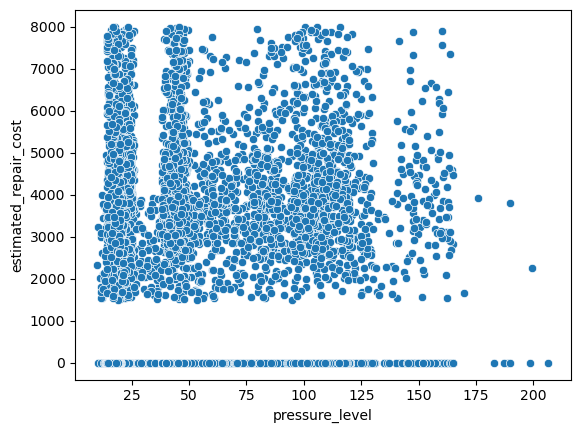

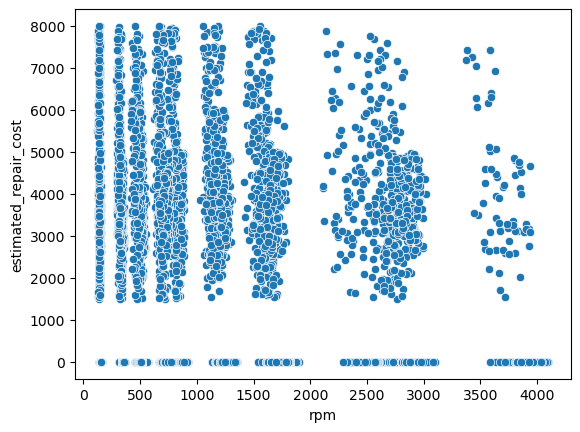

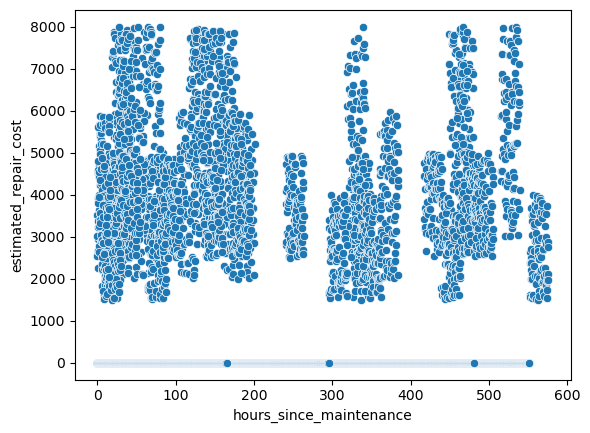

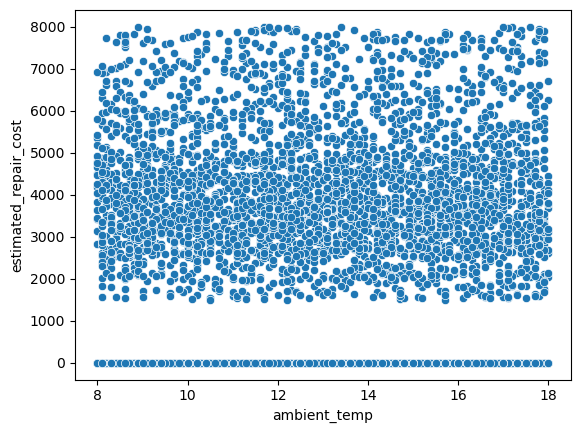

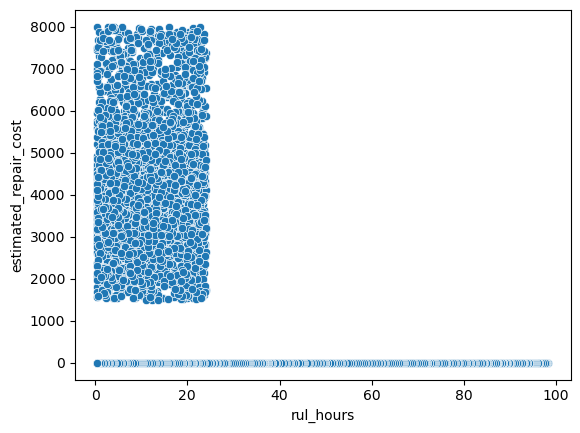

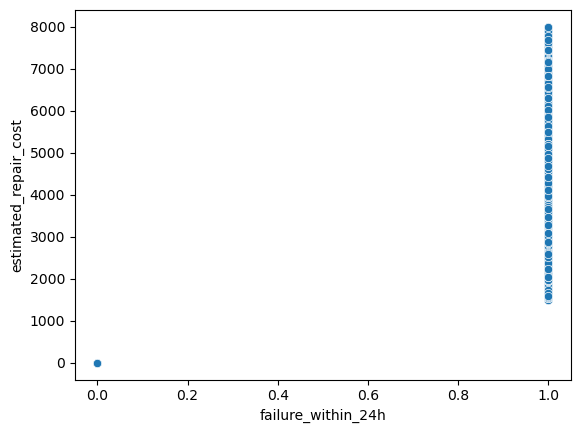

In [12]:
for col in num_cols:
    if col != "estimated_repair_cost":
        sns.scatterplot(x=df[col], y=df["estimated_repair_cost"])
        plt.show()

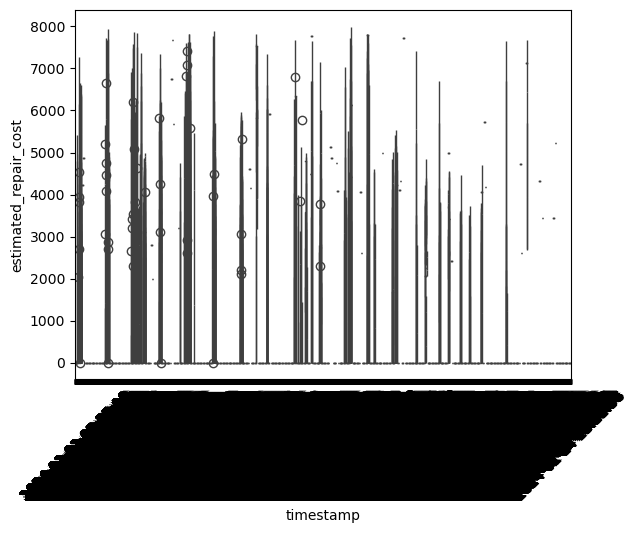

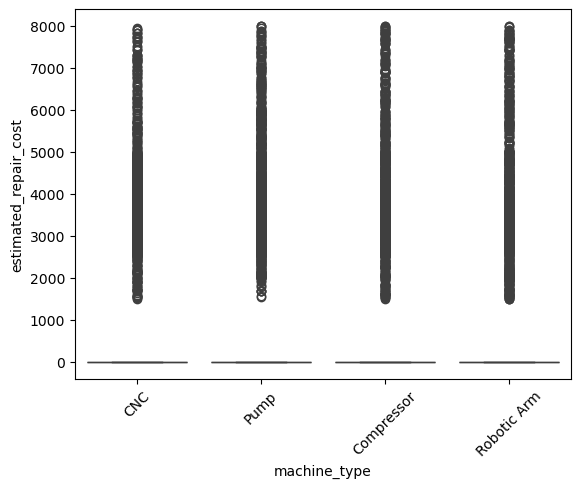

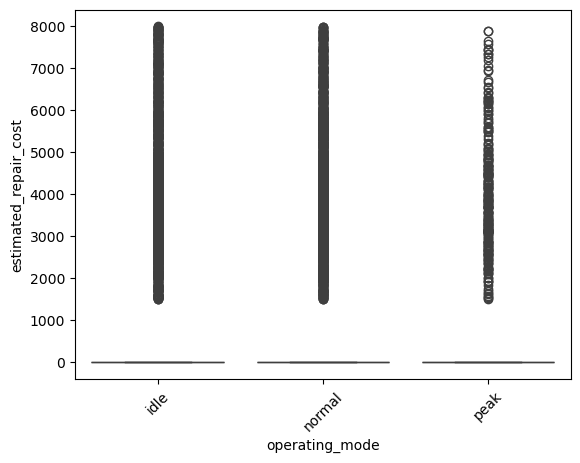

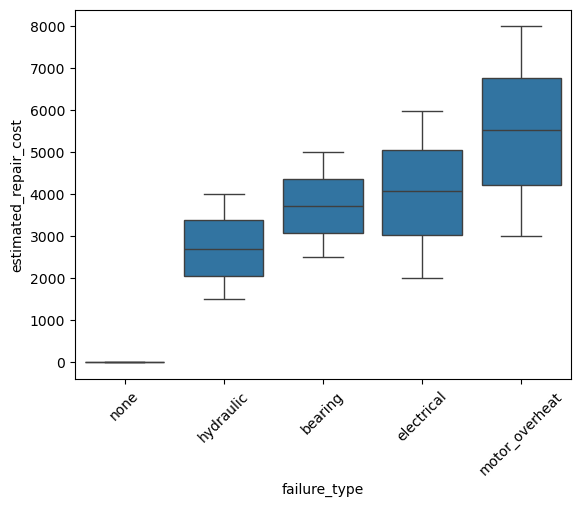

In [13]:
for col in cat_cols:
    sns.boxplot(x=df[col], y=df["estimated_repair_cost"])
    plt.xticks(rotation=45)
    plt.show()